# Additional Alternatives 

Irrelevant alternative instability is an MCDA anomaly in which adding (or removing) an irrelevant alternative can
change the pairwise ranking between two other alternatives. This is a known weakness of normalization-dependent methods such as TOPSIS,
where the ideal and anti-ideal solutions can shift whenever a new alternative is added to the dataset.  Other methods, e.g., SPOTIS and SAW, are more robust because their scores depend only on the criteria bounds or the weight-value product, not on the full set of alternatives.

In this notebook, we use VISTA to visually inspect how the preference landscape deforms when a third alternative is introduced.

In [1]:
%matplotlib inline

from mcda_vista import (
    generate_vista,
    plot_vista,
    plot_vista_comparison,
    plot_vista_grid,
    VistaResult,
)
import numpy as np

## 1. Baseline (No Third Alternative)

First, we generate a standard TOPSIS vista with only one reference alternative. This is our baseline against which we will compare all subsequent maps.

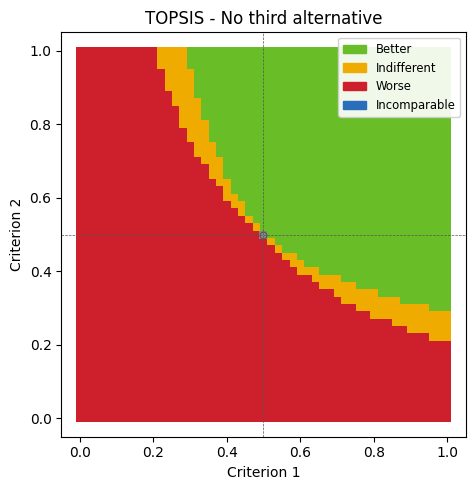

In [4]:
baseline = generate_vista("topsis", resolution=51, delta=0.10, progress=False)

fig = plot_vista(baseline, title="TOPSIS - No third alternative", point_size=27)

## 2. Adding a Third Alternative

We now add a single fixed third alternative at several positions in
the criterion space and regenerate the TOPSIS vista each time.  The triangle
marker shows the location of the third alternative.

Because TOPSIS normalizes the decision matrix, appending a row changes
the ideal and anti-ideal vectors and, consequently, the distance
calculations for every other alternative.  Even though the third alternative is not directly compared, it reshapes the entire preference
landscape.

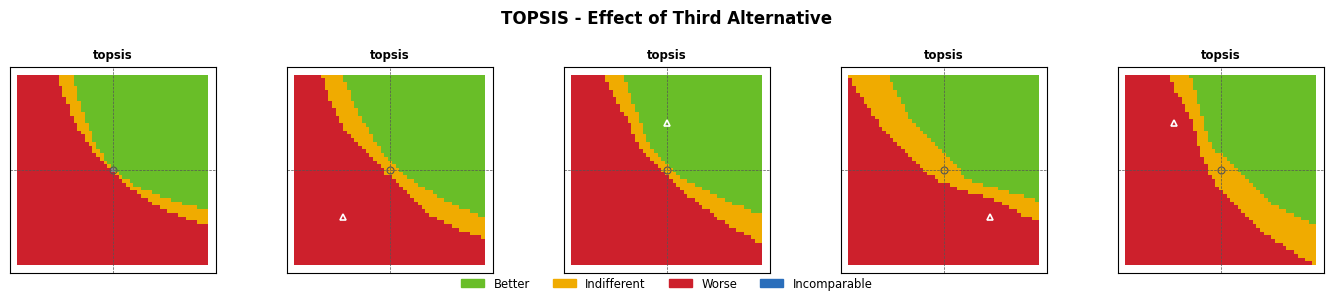

In [6]:
third_alt_positions = [
    None,
    [0.25, 0.25],
    [0.50, 0.75],
    [0.75, 0.25],
    [0.25, 0.75],
]

results_third = [
    generate_vista("topsis", resolution=51, delta=0.10, third_alternative=pos, progress=False)
    for pos in third_alt_positions
]

fig = plot_vista_comparison(
    results_third,
    ncols=5,
    title="TOPSIS - Effect of Third Alternative",
    point_size=5
)

The leftmost panel (no triangle) is the baseline.  Each subsequent panel adds a third alternative at a different location. Notice how the decision boundaries deform around the third alternative.

## 3. Comparison with  Other Methods

Not all MCDA methods are equally susceptible to rank reversal.  Below we
compare **TOPSIS**, **SPOTIS**, and **SAW** side by side, with and without
a third alternative at `[0.25, 0.25]`.

- **TOPSIS** normalizes using the full decision matrix, making it
  inherently sensitive to added alternatives.
- **SPOTIS** computes distances from ideal solution bounds that are
  independent of other alternatives, so it should be robust.
- **SAW** (Simple Additive Weighting) multiplies weights by raw
  performance values without inter-alternative normalization, which
  so it should also be robust.

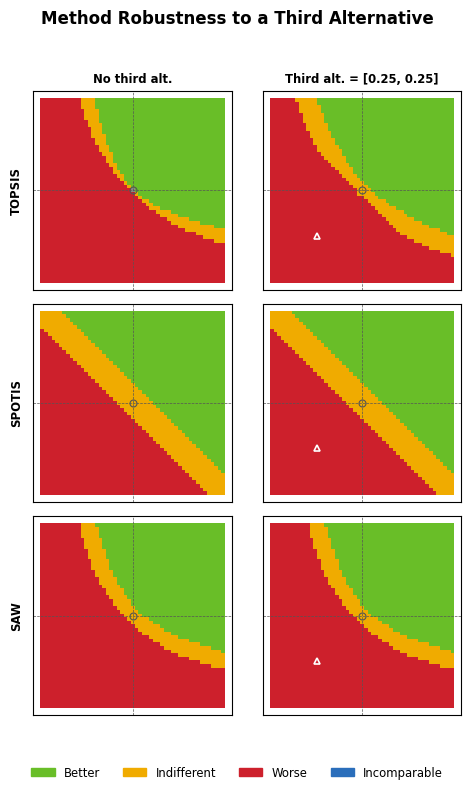

In [7]:
methods = ["topsis", "spotis", "saw"]
method_labels = ["TOPSIS", "SPOTIS", "SAW"]
third_alt = [0.25, 0.25]

grid_results = []
for m in methods:
    row = [
        generate_vista(m, resolution=51, delta=0.10, progress=False),
        generate_vista(m, resolution=51, delta=0.10, third_alternative=third_alt, progress=False),
    ]
    grid_results.append(row)

fig = plot_vista_grid(
    grid_results,
    row_labels=method_labels,
    col_labels=["No third alt.", "Third alt. = [0.25, 0.25]"],
    title="Method Robustness to a Third Alternative",
    point_size=5
)

## 4. Multiple Extra Alternatives

The `extra_alternatives` parameter lets you append several additional
alternatives at once, shown as diamond markers on the plot.
Adding more alternatives can amplify normalization-based distortions.

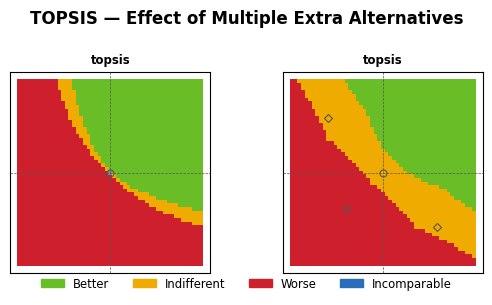

In [9]:
extras = np.array([
    [0.2, 0.8],
    [0.8, 0.2],
    [0.3, 0.3],
])

result_extras = generate_vista(
    "topsis",
    resolution=51,
    delta=0.10,
    extra_alternatives=extras,
    progress=False
)

comparison = [
    baseline,
    result_extras,
]

fig = plot_vista_comparison(
    comparison,
    ncols=2,
    title="TOPSIS - Effect of Multiple Extra Alternatives",
    point_size=5
)

Compared with the baseline (left), the decision boundary in the right panel has shifted noticeably.  The combined effect of three additional points is larger than that of a single third alternative. In a real-world setting, this means that the mere act of expanding the set of options under consideration can change the recommended choice, in some cases, even if the new options are dominated and would never be selected.